UPPGIFT: Grupp projekt i datarening och EDA 13.04.2026

Välj ett valfritt icke-renad dataset (runt 10 eller flera variabler, numeriska och kategoriska/ordinala), förberedd data för EDA (datarening).

Utför en EDA, inklusive statistiska summeringar, statistik med hypotes testning, visualiseringar. Bygg enkel linjär regression och utvärdera dess prestanda.

Frågor: Vad kan du säga om datasetet baserat på din EDA? Finns det några uppenbara mönster eller avvikelser?

Presentation: Beskriv datasetet, variabler. Hur ni renade data, vilka alternativ fanns, vilka problem ni hade med datasetet. Presentera resultat som databerättelse (runt 15 min). Gör en story.

Översikt
Original dataset:

Dataset med bortfall:
Datatyper och struktur - original
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
Datatyper och struktur - med bortfall
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
-

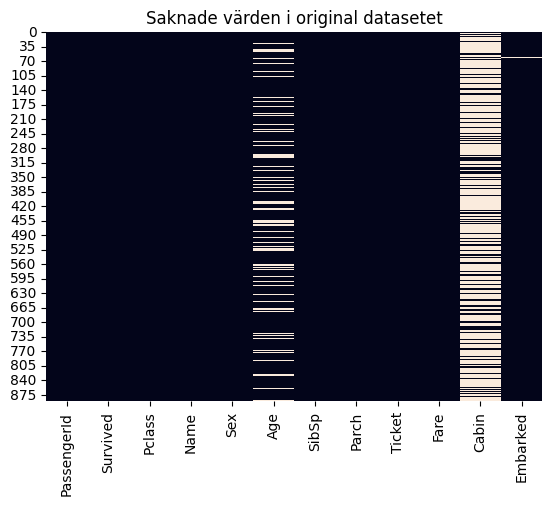

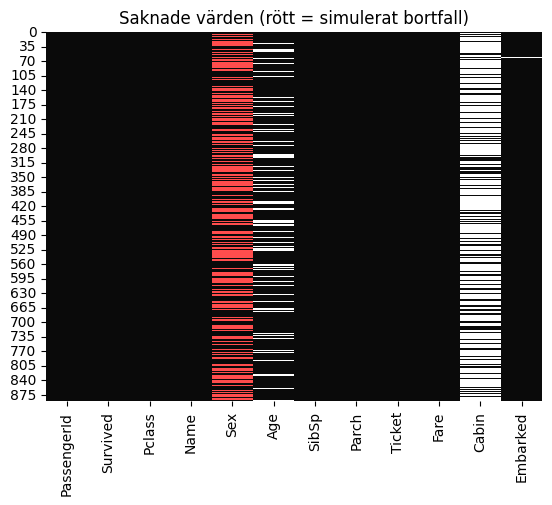

Dubbletter:  0


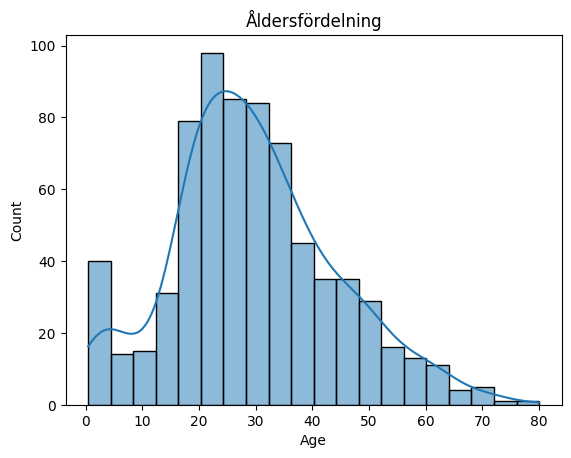


--- Embarked ---
Unika värden:
<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str

Saknade värden: 2

Frekvens:
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

--- Sex ---
Unika värden:
<StringArray>
['male', 'female', nan]
Length: 3, dtype: str

Saknade värden: 445

Frekvens:
Sex
NaN       445
male      297
female    149
Name: count, dtype: int64

Tomma strängar:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Felaktiga värden:
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     

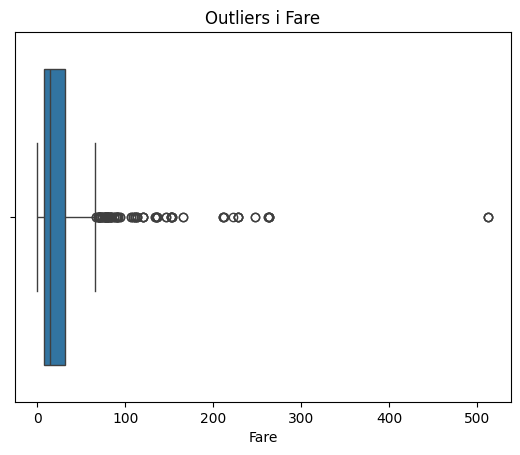

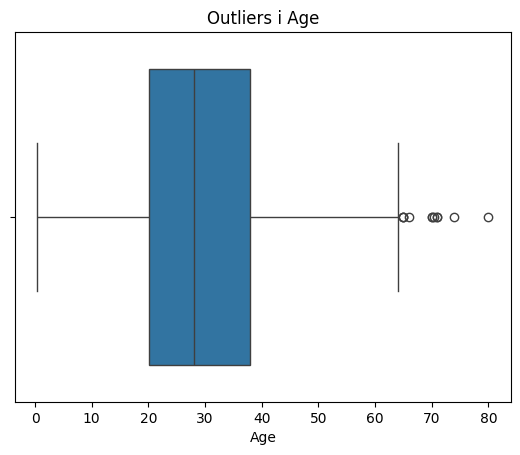


Datatyper:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object


In [32]:
# Importera bibliotek

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap


# Ladda dataset
df_original = pd.read_csv("/Users/victoria/Documents/aikurs/02_datareningEDA/train.csv")
df_bortfall = pd.read_csv("/Users/victoria/Documents/aikurs/02_datareningEDA/train_bortfall.csv")

# OVERVIEW
print("Översikt")
print("Original dataset:")
df_original.head(10)
print("\nDataset med bortfall:")
df_bortfall.head(10)


# Datatypes and Structure
print("Datatyper och struktur - original")
df_original.info()
print("Datatyper och struktur - med bortfall")
df_bortfall.info()

# Missing values
print("Saknade värden - Original:")
print(df_original.isna().sum())

print("Saknade värden - Dataset med bortfall:")
print(df_bortfall.isna().sum())

# Visualisation of original and corrupted data
print("Visualisering av original data")
sns.heatmap(df_original.isna(), cbar=False)
plt.title("Saknade värden i original datasetet")
plt.show()


# Heatmap of corrupted data (in red)
orig_na = df_original.isna()
bortfall_na = df_bortfall.isna()

new_missing = bortfall_na & ~orig_na
visual = np.zeros(df_bortfall.shape)

visual[orig_na] = 1          # original missing → white
visual[new_missing] = 2      # new missing → red

cmap = ListedColormap(["#0a0a0a", "#ffffff", "#ff4d4d"])
# black = data, white = original NaN, red = new NaN

sns.heatmap(visual, cmap=cmap, cbar=False, xticklabels=df_bortfall.columns)
plt.title("Saknade värden (rött = simulerat bortfall)")
plt.show()

# DUBBLETTER
print("Dubbletter: ", df_bortfall.duplicated().sum())

# Ålder
sns.histplot(df_bortfall['Age'], kde=True)
plt.title("Åldersfördelning")
plt.show()

# INKONSEKVENTA FORMAT
def check_categorical(column):
    print(f"\n--- {column.name} ---")
    
    # Unique values
    print("Unika värden:")
    print(column.unique())
    
    # Missing values
    print("\nSaknade värden:", column.isna().sum())
    
    # Count values
    print("\nFrekvens:")
    print(column.value_counts(dropna=False))

check_categorical(df_bortfall['Embarked'])
check_categorical(df_bortfall['Sex'])

# TOMMA STRÄNGER
print("\nTomma strängar:")
print((df_bortfall == "").sum())

# FELAKTIGA VÄRDEN
print("\nFelaktiga värden:")

# Summary
print(df_bortfall.describe())

# Logical checks
print("\nNegativ ålder:", (df_bortfall['Age'] < 0).sum())
print("Negativ biljettpris:", (df_bortfall['Fare'] < 0).sum())


# OUTLIERS
sns.boxplot(x=df_bortfall['Fare'])
plt.title("Outliers i Fare")
plt.show()

sns.boxplot(x=df_bortfall['Age'])
plt.title("Outliers i Age")
plt.show()

# KONVERTERING AV KATEGORISKA VARIABLER
print("\nDatatyper:")
print(df_bortfall.dtypes)

dataset: Kaggle-datasetet Titanic (orensat) med 50 % bortfall av könsvariabeln

10+ variabler:

1. PassengerID (passengerareID) - int64 måste vara unique
2. Survived (överlevde) - int64
3. Pclass (biljettklass) - int64
4. Name (namn) - str
5. Sex (kön) - str
6. Age (ålder)  - float64 - float (not int) and missing values
7. SibSp (syskon och maka) - int64
8. Parch (barn eller föräldrar) - int64
9. Ticket (biljettnummer) - str
10. Fare (biljettpris) - float64
11. Cabin (hyttnummer) - str - många missing values
12. Embarked (ombordstigningshamn) - str - missing values

Ombordstigningshamn (Embarked): Kategorisk variabel med väldigt lite bortfall (2 värden, <1% saknade).
➡️ Vi ersätter med typvärde

Ålder (Age): Numerisk variabel med bortfall och snedfördelning.
➡️ Vi ersätter med median för att minska påverkan av extremvärden

Hyttnummer (Cabin): Mycket stort bortfall (~77% saknade), vilket gör det svårt att ersätta värden utan att skapa bias. Variabeln är kategorisk (textbaserad - sträng).
➡️ Vi markerar saknade värden som “Unknown” istället för att ta bort data

Kön (Sex): Kategorisk variabel med stort bortfall (~50% saknade). Att ta bort rader skulle kraftigt minska datasetet.
➡️ Vi ersätter med typvärde (mode). 
⭐ Alternativ: härleda från titlar i namn (t.ex. namnen som har “Mr.”, “Master.” eller “Rev.” →  male, och “Miss.”, “Mrs.” eller “Madame” → female)


Saknade värden efter rensning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Dubbletter: 0

--- Embarked ---
Unika värden:
<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

Saknade värden: 0

Frekvens:
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64

--- Sex ---
Unika värden:
<StringArray>
['male', 'female']
Length: 2, dtype: str

Saknade värden: 0

Frekvens:
Sex
male      742
female    149
Name: count, dtype: int64

Tomma strängar:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Felaktiga värden efter kontroll:
Negativ ålder: 0
Negativ fare: 0

Antal outliers: 116


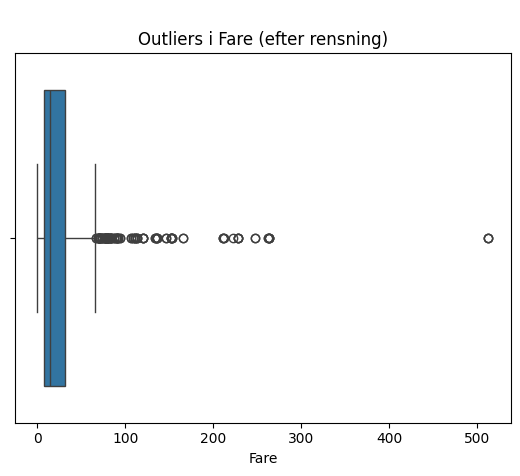

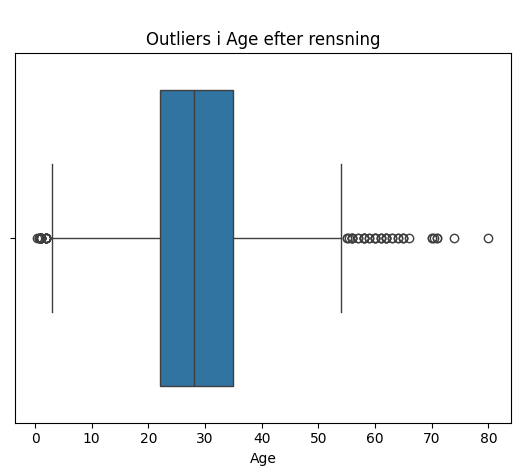


Konvertering av Kategoriska Variabler

Datatyper efter konvertering:
PassengerId       int64
Survived          int64
Pclass         category
Name                str
Sex            category
Age             float64
SibSp             int64
Parch             int64
Ticket              str
Fare            float64
Cabin          category
Embarked       category
dtype: object


In [ ]:
""" Datarening """

df_clean = df_bortfall.copy()

# Saknade värden
df_clean['Embarked'] = df_clean['Embarked'].fillna(df_clean['Embarked'].mode()[0])
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median())
df_clean['Cabin'] = df_clean['Cabin'].fillna('Unknown')
df_clean['Sex'] = df_clean['Sex'].fillna(df_clean['Sex'].mode()[0])

        # härleda från titlar i namn?

print("\nSaknade värden efter rensning:")
print(df_clean.isna().sum())


# Dubbletter
df_clean = df_clean.drop_duplicates()
print("\nDubbletter:", df_clean.duplicated().sum())

# Inkonsekventa Format
check_categorical(df_clean['Embarked'])
check_categorical(df_clean['Sex'])

# Tomma strängar 
print("\nTomma strängar:")
print((df_clean == "").sum())

# Felaktiga värden

print("\nFelaktiga värden efter kontroll:")
print("Negativ ålder:", (df_clean['Age'] < 0).sum())
print("Negativ fare:", (df_clean['Fare'] < 0).sum())

# Outliers
Q1 = df_clean['Fare'].quantile(0.25)
Q3 = df_clean['Fare'].quantile(0.75)
IQR = Q3 - Q1

outliers = df_clean[(df_clean['Fare'] < (Q1 - 1.5 * IQR)) |
                    (df_clean['Fare'] > (Q3 + 1.5 * IQR))]

print("\nAntal outliers:", len(outliers))


sns.boxplot(x=df_clean['Fare'])
plt.title("\nOutliers i Fare (efter rensning)")
plt.show()

sns.boxplot(x=df_clean['Age'])
plt.title("\nOutliers i Age efter rensning")
plt.show()

# Konvertering av Kategoriska Variabler
print("\nKonvertering av Kategoriska Variabler")
# Dessa variabler representerar kategorier (kön, klass, hyttnummer och ombordstigningshamn)
df_clean['Sex'] = df_clean['Sex'].astype('category')
df_clean['Embarked'] = df_clean['Embarked'].astype('category')
df_clean['Cabin'] = df_clean['Cabin'].astype('category')
df_clean['Pclass'] = df_clean['Pclass'].astype('category')
print("\nDatatyper efter konvertering:")
print(df_clean.dtypes)



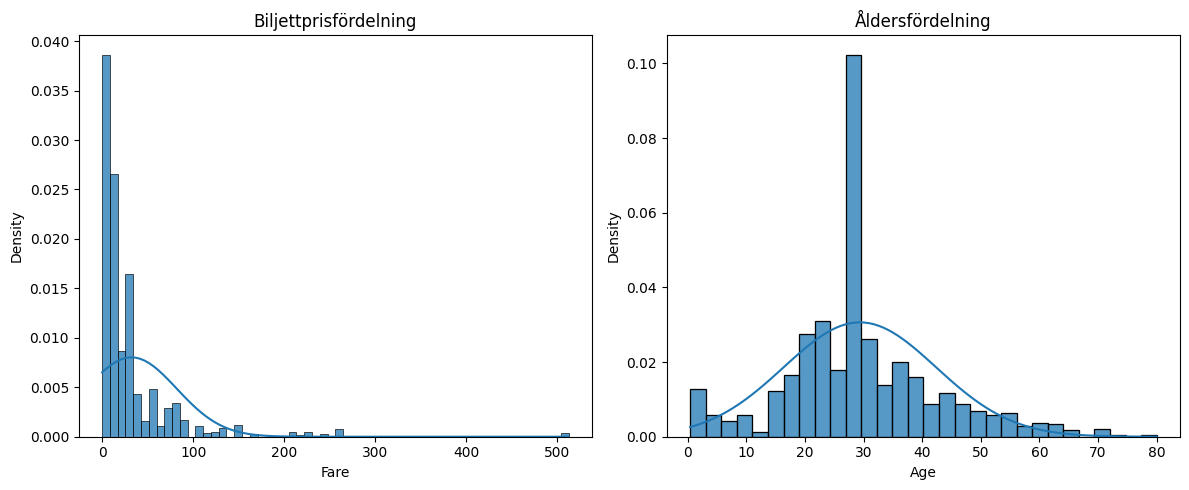

In [ ]:
import numpy as np
import scipy.stats as stats

# Create figure with two plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- FARE ---
mean_fare = df_clean['Fare'].mean()
std_fare = df_clean['Fare'].std()
x_fare = np.linspace(df_clean['Fare'].min(), df_clean['Fare'].max(), 100)

sns.histplot(df_clean['Fare'], stat="density", ax=axes[0])
axes[0].plot(x_fare, stats.norm.pdf(x_fare, mean_fare, std_fare))
axes[0].set_title("Biljettprisfördelning")

# --- AGE ---
mean_age = df_clean['Age'].mean()
std_age = df_clean['Age'].std()
x_age = np.linspace(df_clean['Age'].min(), df_clean['Age'].max(), 100)

sns.histplot(df_clean['Age'], stat="density", ax=axes[1])
axes[1].plot(x_age, stats.norm.pdf(x_age, mean_age, std_age))
axes[1].set_title("Åldersfördelning")

plt.tight_layout()
plt.show()